# Práctica 3: Gradiente, Combinador Lineal y Regresión

## Ejercicio 1

Dada la función $$f(x,y) = \frac{x}{(2x^2+3y^2+1)}$$ cuyas derivad parciales son $$\frac{\partial f(x,y)}{\partial x} = \frac{-2x^2+3y^2+1}{(2x^2+3y^2+1)^2}$$ $$\frac{\partial f(x,y)}{\partial y} = \frac{-6xy}{(2x^2+3y^2+1)^2}$$

1. Indique el vector gradiente para $𝑥 = 1$ e $𝑦 = −1$
2. Si a partir de $(𝑥 = 0.20;\ 𝑦 = −1)$ tuviera que elegir una dirección en la cual la función crezca, qué acción tomaría?
   1. Incrementar los valores de $x$ e $y$
   2. Disminuir los valores de $x$ e $y$
   3. Incrementar el valor de $x$ y disminuir el de $y$
   4. Disminuir el valor de $x$ e incrementar el de $y$
3. Una vez elegida la dirección en b), el movimiento a realizar será una fracción del módulo del vector gradiente. ¿Cuál sería la nueva posición si se considera $𝑎𝑙𝑓𝑎 = 0.1$? ¿cuál es el valor de la función en la nueva ubicación?
4. Considere nuevamente las opciones del inciso b) pero ahora debe buscar una dirección, a partir de $(𝑥 = 0.20; 𝑦 = −1)$, en la cual la función disminuya ¿cuál sería su elección?
5. Repita lo solicitado en c) para la dirección elegida en d) donde el objetivo fue hallar una ubicación donde la función tome un valor menor.
6. Utilice la técnica del descenso de gradiente para calcular el valor y la ubicación del mínimo de la función $𝑓(𝑥,𝑦)$ que se observa en la figura.
7. Idem f) para el máximo de la función $𝑓(𝑥,𝑦)$

### Respuestas

2. Como al evaluar vemos que los 2 resultados del vector gradiente son positivos y nosotros buscamos crecer, lo que debemos hacer es incrementar los valores de $x$ e $y$, es decir, la primera opción.
4. Como al evaluar vemos que los 2 resultados del vector gradiente son positivos y lo que nosotros buscamos es minimizar, lo que debemos hacer es decrementar los valores de $x$ e $y$, es decir, la segunda opción.

In [1]:
from sympy import symbols, diff
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sympy import lambdify

# establece variables a usar en la funcion
x, y= symbols('x y', real=True)

# define la funcion
f = x/(2*x**2 + 3*y*y + 1)
print("--------------------FUNCIÓN ORIGINAL--------------------")
f

--------------------FUNCIÓN ORIGINAL--------------------


x/(2*x**2 + 3*y**2 + 1)

In [2]:
# derivada parcial x
df_dx = diff(f, x)
print("--------------------DERIVADA PARCIAL X--------------------")
df_dx

--------------------DERIVADA PARCIAL X--------------------


-4*x**2/(2*x**2 + 3*y**2 + 1)**2 + 1/(2*x**2 + 3*y**2 + 1)

In [3]:
# derivada parcial y
df_dy = diff(f, y)
print("--------------------DERIVADA PARCIAL Y--------------------")
df_dy

--------------------DERIVADA PARCIAL Y--------------------


-6*x*y/(2*x**2 + 3*y**2 + 1)**2

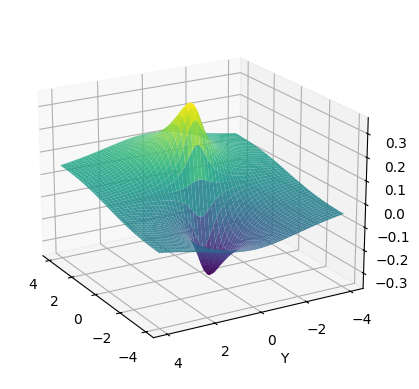

In [4]:
# grafica de la funcion en cuestion
# Malla de puntos para graficar
X = np.linspace(-4, 4, 100)
Y = np.linspace(-4, 4, 100)
X, Y = np.meshgrid(X, Y)
Z = lambdify((x, y), f, 'numpy')(X, Y)

# Graficar
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.view_init(elev=20, azim=150)
ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.9)

ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.show()

In [5]:
# Evaluar el gradiente en (1, -1)
grad_x = df_dx.subs({x: 1, y: -1})
grad_y = df_dy.subs({x: 1, y: -1})

gradiente = (grad_x, grad_y)

print("Gradiente en (1, -1):", gradiente)

Gradiente en (1, -1): (1/18, 1/6)


In [6]:
# Evaluar el gradiente en (0.20, -1)
grad_x = df_dx.subs({x: 0.20, y: -1})
grad_y = df_dy.subs({x: 0.20, y: -1})

gradiente = (grad_x, grad_y)

print("Gradiente en (0.20, -1):", gradiente)

# calculamos el paso
alpha = 0.1

nuevo_x = 0.20 + alpha * grad_x
nuevo_y = -1 + alpha * grad_y

# valor de la función en la nueva pos
f_nuevo = f.subs({x: nuevo_x, y: nuevo_y})

print("Nueva posición:", (nuevo_x, nuevo_y))
print("Valor de la función en la nueva posición:", f_nuevo)

Gradiente en (0.20, -1): (0.235486351403306, 0.0720876585928489)
Nueva posición: (0.223548635140331, -0.992791234140715)
Valor de la función en la nueva posición: 0.0551039757815892


In [7]:
# # Evaluar el gradiente en (0.20, -1)
grad_x = df_dx.subs({x: 0.20, y: -1})
grad_y = df_dy.subs({x: 0.20, y: -1})

gradiente = (grad_x, grad_y)

print("Gradiente en (0.20, -1):", gradiente)

# calculamos el paso
alpha = 0.1

nuevo_x = 0.20 - alpha * grad_x
nuevo_y = -1 - alpha * grad_y

# valor de la función en la nueva pos
f_nuevo = f.subs({x: nuevo_x, y: nuevo_y})

print("Nueva posición:", (nuevo_x, nuevo_y))
print("Valor de la función en la nueva posición:", f_nuevo)

Gradiente en (0.20, -1): (0.235486351403306, 0.0720876585928489)
Nueva posición: (0.176451364859669, -1.00720876585928)
Valor de la función en la nueva posición: 0.0429773928670840


In [8]:
# descenso de gradiente buscando el mínimo

# Convertimos a funciones evaluables con numpy
f_lambd = lambdify((x,y), f, "numpy")
df_dx_lambd = lambdify((x,y), df_dx, "numpy")
df_dy_lambd = lambdify((x,y), df_dy, "numpy")

alpha = 0.1       # tasa de aprendizaje
tol = 1e-6        # tolerancia
max_iter = 300    # máximo de iteraciones

# Punto inicial
x_curr, y_curr = 0.20, -1.0

for i in range(max_iter):
    grad_x = df_dx_lambd(x_curr, y_curr)
    grad_y = df_dy_lambd(x_curr, y_curr)
    
    # Actualizar posición (descenso => restamos gradiente)
    x_new = x_curr - alpha * grad_x
    y_new = y_curr - alpha * grad_y
    
    # Chequear convergencia
    if np.sqrt((x_new - x_curr)**2 + (y_new - y_curr)**2) < tol:
        break
    
    x_curr, y_curr = x_new, y_new

print("Iteraciones:", i)
print("Mínimo aproximado en:", (x_curr, y_curr))
print("Valor mínimo aproximado de f:", f_lambd(x_curr, y_curr))

Iteraciones: 178
Mínimo aproximado en: (-0.7071199927830556, -3.1143054109284157e-07)
Valor mínimo aproximado de f: -0.3535533905315121


In [9]:
# ascenso de gradiente

# Punto inicial
x_curr, y_curr = 0.20, -1.0

for i in range(max_iter):
    grad_x = df_dx_lambd(x_curr, y_curr)
    grad_y = df_dy_lambd(x_curr, y_curr)
    
    # Actualizar posición (descenso => restamos gradiente)
    x_new = x_curr + alpha * grad_x
    y_new = y_curr + alpha * grad_y
    
    # Chequear convergencia
    if np.sqrt((x_new - x_curr)**2 + (y_new - y_curr)**2) < tol:
        break
    
    x_curr, y_curr = x_new, y_new

print("Iteraciones:", i)
print("Máximo aproximado en:", (x_curr, y_curr))
print("Valor máximo aproximado de f:", f_lambd(x_curr, y_curr))

Iteraciones: 160
Máximo aproximado en: (0.7071200856679184, -3.286593721579173e-07)
Valor máximo aproximado de f: 0.3535533905306354


## Ejercicio 2

El precio de una vivienda está dado por dos factores, la proximidad a centros comerciales, financieros, vías y demás que se mide a través del factor $j$, y de la condición misma de la vivienda que se mide por el factor $k$. La relación entre estos factores y el precio de la vivienda en un barrio determinado está dada por: $$P(j,k) = k^2-2jk +2j^2+18j-20k+201$$ donde el precio está dado en miles de dólares.

Utilice la técnica de descenso de gradiente para determinar los valores de $j$ y $k$ que minimizan el precio de la vivienda.

In [10]:
# Variables simbólicas
j, k = symbols('j k', real=True)

# Función precio
P = k*k - 2*j*k + 2*j*j + 18*j - 20*k + 201

# Gradiente
dP_dj = diff(P, j)
dP_dk = diff(P, k)

# Convertimos a funciones evaluables con numpy
P_np = lambdify((j,k), P, 'numpy')
grad_j = lambdify((j,k), dP_dj, 'numpy')
grad_k = lambdify((j,k), dP_dk, 'numpy')

# Parámetros
alpha = 0.1
tol = 1e-6
max_iter = 300

# Punto inicial
j_curr, k_curr = 0.0, 0.0

for i in range(max_iter):
    dj = grad_j(j_curr, k_curr)
    dk = grad_k(j_curr, k_curr)
    
    # Descenso de gradiente
    j_new = j_curr - alpha * dj
    k_new = k_curr - alpha * dk
    
    # Convergencia
    if np.sqrt((j_new - j_curr)**2 + (k_new - k_curr)**2) < tol:
        break
    
    j_curr, k_curr = j_new, k_new

print("Iteraciones:", i)
print("Mínimo aproximado en (j, k):", (j_curr, k_curr))
print("Precio mínimo aproximado:", P_np(j_curr, k_curr))

Iteraciones: 171
Mínimo aproximado en (j, k): (0.9999934845371268, 10.999989457759618)
Precio mínimo aproximado: 100.00000000005866


## Ejercicio 3

A continuación, se presentan datos de entrenamiento y tiempo promedio de un recorrido de corredores para una distancia fija. Los datos están organizados en una tabla con las horas de entrenamiento semanales y el tiempo promedio en minutos para completar el recorrido:

| Horas de Entrenamiento | Tiempo Promedio (min) |
|------------------------|-----------------------|
| 2 | 30.5 |
| 3 | 29.3 |
| 4 | 26.7 |
| 4 | 26.0 |
| 5 | 25.5 |
| 6 | 24.7 |
| 6 | 23.5 |
| 7 | 23.0 |
| 7 | 22.5 |
| 8 | 21.0 |
| 10 | 21.0 |
| 10 | 20.5 |

A partir de los datos de entrenamiento y tiempos de recorrido de los corredores, se desea obtener la recta de regresión que permita predecir el tiempo promedio que un corredor tardará en recorrer la distancia fija a partir de las horas de entrenamiento semanales. Responder:

1. Calcule la correlación lineal entre estas dos variables y dibuje el diagrama de dispersión correspondiente. ¿La recta de regresión será de utilidad?
2. Indique la ecuación del error cuadrático medio que se debería minimizar si se utilizara la técnica de descenso de gradiente.
3. Indique la ecuación de error que se minimiza al utilizar la técnica de descenso de gradiente estocástico. ¿Qué ventaja tiene su uso con respecto a la ecuación indicada en b)?
4. Utilice la técnica de descenso de gradiente estocástico para obtener los coeficientes de la recta de regresión que permita predecir el tiempo promedio que un corredor tardará en recorrer la distancia fija a partir de las horas de entrenamiento semanales.
5. Utilice la recta obtenida en d) para predecir el tiempo promedio que tardará en recorrer la distancia fija un corredor que entrena 9 horas semanales.

### Respuestas

1. Para poder decir que la recta de regresión será útil tenemos que tener en cuenta que se necesita una correlación lineal fuerte, en este caso eso pasa asi que sí, la recta de regresión será útil.
2.  La función de costo a minimizar es el $MSE$, pero suele escribirse con un factor $\frac{1}{2m}$ para simplificar las derivadas: $$J(\beta_0, \beta_1) = \frac{1}{2m} \sum_{i=1}^{m} \left( \hat{y}_i - y_i \right)^2$$ Ya que las derivadas quedan de esta forma: $$ \frac{\partial J}{\partial \beta_0} = \frac{1}{m} \sum_{i=1}^{m} \left( \hat{y}_i - y_i \right)$$ $$\frac{\partial J}{\partial \beta_1} = \frac{1}{m} \sum_{i=1}^{m} \left( \hat{y}_i - y_i \right) x_i$$
3.  Cuando usamos el descenso de gradiente estocástico ($SGD$), en lugar de calcular el error sobre todos los datos en cada iteración, se calcula ejemplo por ejemplo. La función de error para un solo ejemplo $(x_i, y_i)$ es: $$E_i(\beta_0, \beta_1) = \frac{1}{2} \left( y_i - \hat{y}_i \right)^2$$ Donde: $$\hat{y}_i = \beta_0 + \beta_1 x_i$$ Ventajas:
- Mucho más rápido para datasets grandes (actualiza en cad observación)
- Tiende a escapar de mínimos locales.
- En la práctica converge antes a una buena solución aproximada, aunque con más "ruido" en las actualizaciones.

Correlación lineal: -0.959746386006859


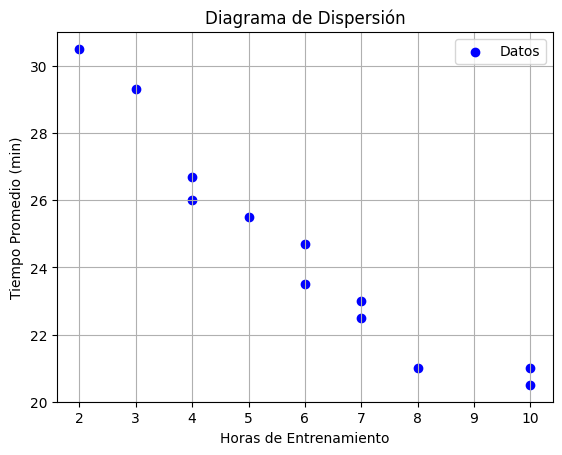

In [11]:
# Datos
horas_entrenamiento = np.array([2, 3, 4, 4, 5, 6, 6, 7, 7, 8, 10, 10])
tiempo_promedio = np.array([30.5, 29.3, 26.7, 26.0, 25.5, 24.7, 23.5, 23.0, 22.5, 21.0, 21.0, 20.5])

correlacion = np.corrcoef(horas_entrenamiento, tiempo_promedio)[0,1]
print("Correlación lineal:", correlacion)

plt.scatter(horas_entrenamiento, tiempo_promedio, color='blue', label='Datos')
plt.xlabel("Horas de Entrenamiento")
plt.ylabel("Tiempo Promedio (min)")
plt.title("Diagrama de Dispersión")
plt.grid(True)
plt.legend()
plt.show()

In [12]:
# Parametros iniciales
beta_0 = 0.0   # Intercepto/Ordenada al Origen
beta_1 = 0.0   # Pendiente
alpha = 0.01   # Tasa de aprendizaje
epochs = 1000  # Número de iteraciones

m = len(horas_entrenamiento) # Cantidad de observaciones

# Descenso de gradiente estocástico
for epoch in range(epochs): # Recorremos el dataset varias veces
    for i in range(m):  # Vamos ejemplo por ejemplo (SGD)
        xi = horas_entrenamiento[i] # Horas de entrenamiento del corredor i
        yi = tiempo_promedio[i]  # Tiempo promedio real del corredor i
        y_pred = beta_0 + beta_1 * xi # Predicción del modelo para este corredor
        
        # Calculamos el error de predicción
        error = yi - y_pred 

        # Gradientes (derivadas del error respecto a los parámetros)
        grad_b0 = -error # Derivada respecto a beta_0
        grad_b1 = -error * xi # Derivada respecto a beta_1
        
        # Actualización de parámetros usando la tasa de aprendizaje
        beta_0 -= alpha * grad_b0
        beta_1 -= alpha * grad_b1

print(f"Coeficientes finales: beta_0 = {beta_0:.4f}, beta_1 = {beta_1:.4f}")

Coeficientes finales: beta_0 = 31.2527, beta_1 = -1.0758


In [13]:
# Prediccion
valor_x = 9
print("Predicción para 9 horas de entrenamiento:", (beta_0 + beta_1 * valor_x))

Predicción para 9 horas de entrenamiento: 21.57055764982585


## Ejercicio 4

El archivo ccpp.csv contiene 9568 datos de una central de ciclo combinado recolectados entre 2006 y 2011. Usando la totalidad de los ejemplos se entrenaron 5 combinadores lineales con el objetivo de predecir el valor del atributo PE correspondiente a la cantidad de energía producida a partir del atributo AT (más 
detalles de este conjunto de datos aquí). Indique cuáles son los dos combinadores lineales con menor error cuadrático promedio a la hora de predecir el valor de PE en función de AT:

1. $W = -2.00;\ b = 500$
2. $W = -2.21;\ b = 498$
3. $W = -2.30;\ b = 497$
4. $W = -2.22;\ b = 496.5$
5. $W = -2.16;\ b = 496.91$

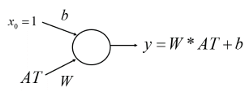

In [14]:
import pandas as pd

# nos traemos el csv
df_ccpp = pd.read_csv(r"C:\Users\Usuario\Desktop\FACULTAD\4to_Año\segundo_semestre\Aprendizaje Automatico Profundo\practicas\resoluciones\datasets\CCPP.csv")

# chequeamos que esté bien
print(df_ccpp.head())    # vemos las primeras filas
df_ccpp.shape    # vemos cantidad de filas y columnas
df_ccpp.info()     # vemos tipos de datos
df_ccpp.describe() # vemos estadísticas de las columnas numéricas
nulos = df_ccpp.isnull().sum()
porcentaje_nulos = (df_ccpp.isnull().mean() * 100).round(2)
valores_nulos = pd.DataFrame({
    "Valores Nulos": nulos,
    "Porcentaje (%)": porcentaje_nulos
})
print("--------------------NULOS Y PORCENTAJE--------------------")
print(valores_nulos)

      AT      V       AP     RH      PE
0  14.96  41.76  1024.07  73.17  463.26
1  25.18  62.96  1020.04  59.08  444.37
2   5.11  39.40  1012.16  92.14  488.56
3  20.86  57.32  1010.24  76.64  446.48
4  10.82  37.50  1009.23  96.62  473.90
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9568 entries, 0 to 9567
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      9568 non-null   float64
 1   V       9568 non-null   float64
 2   AP      9568 non-null   float64
 3   RH      9568 non-null   float64
 4   PE      9568 non-null   float64
dtypes: float64(5)
memory usage: 373.9 KB
--------------------NULOS Y PORCENTAJE--------------------
    Valores Nulos  Porcentaje (%)
AT              0             0.0
V               0             0.0
AP              0             0.0
RH              0             0.0
PE              0             0.0


In [15]:
import sys
sys.path.append(r"C:\Users\Usuario\Desktop\FACULTAD\4to_Año\segundo_semestre\Aprendizaje Automatico Profundo\FUENTES")
from ClassNeuronaLineal import NeuronaLineal
from sklearn.metrics import mean_squared_error

X = df_ccpp[['AT']].values
y = df_ccpp['PE'].values

modelos = {
    "a": (-2.00, 500),
    "b": (-2.21, 498),
    "c": (-2.30, 497),
    "d": (-2.22, 496.5),
    "e": (-2.16, 496.91),
}

resultados = {}

for nombre, (W, b) in modelos.items():
    neurona = NeuronaLineal()
    neurona.w_ = np.array([W], dtype=float)
    neurona.b_ = float(b)
    y_pred = neurona.predict(X)
    mse = mean_squared_error(y, y_pred)
    resultados[nombre] = mse
    print(f"Modelo {nombre}: W={W}, b={b}, MSE={mse:.4f}")

# Ordenamos por menor MSE
mejores = sorted(resultados.items(), key=lambda x: x[1])[:2]
print("\nLos dos mejores modelos son:")
for nombre, mse in mejores:
    print(f"Modelo {nombre} con MSE={mse:.4f}")

Modelo a: W=-2.0, b=500, MSE=71.1626
Modelo b: W=-2.21, b=498, MSE=29.5571
Modelo c: W=-2.3, b=497, MSE=36.9194
Modelo d: W=-2.22, b=496.5, MSE=31.7856
Modelo e: W=-2.16, b=496.91, MSE=29.4485

Los dos mejores modelos son:
Modelo e con MSE=29.4485
Modelo b con MSE=29.5571


## Ejercicio 5

A partir de los ejemplos del archivo automobile-simple.csv, utilizado en la práctica anterior, se entrenará un combinador lineal para predecir el precio del auto (atributo “price”) en función del tamaño del motor (atributo “engine-size”):

1. Antes de comenzar con el entrenamiento, complete los datos faltantes del atributo “price” utilizando el valor promedio.
2. Luego de completar según lo indicado en a), realice el entrenamiento del combinador lineal:
    1. Sin normalizar los atributos.
    2. Normalizando ambos atributos linealmente.
    3. Normalizando ambos atributos utilizando media y desvío.

Analice el impacto de la normalización en el entrenamiento. ¿Qué resultados obtuvo sin normalizar los atributos? ¿Alguna de las normalizaciones es mejor? Explique.

### Respuesta

Cuando no se normaliza tenemos que usar un alpha muy chico ya que sino todos los cálculos dan Overflow, además el MSE se dispara con datos no normalizados. Dentro de las 2 neuronas normalizadas la que tiene un mejor rendimiento creo que es la lineal ya que tiene un MSE más chico.

In [16]:
# nos traemos el csv
df_autos_simple = pd.read_csv(r"C:\Users\Usuario\Desktop\FACULTAD\4to_Año\segundo_semestre\Aprendizaje Automatico Profundo\practicas\resoluciones\datasets\automobile-simple.csv")

# chequeamos que esté bien
print(df_autos_simple.head())    # vemos las primeras filas
df_autos_simple.shape    # vemos cantidad de filas y columnas
df_autos_simple.info()     # vemos tipos de datos
df_autos_simple.describe() # vemos estadísticas de las columnas numéricas
nulos = df_autos_simple.isnull().sum()
porcentaje_nulos = (df_autos_simple.isnull().mean() * 100).round(2)
valores_nulos = pd.DataFrame({
    "Valores Nulos": nulos,
    "Porcentaje (%)": porcentaje_nulos
})
print("--------------------NULOS Y PORCENTAJE--------------------")
print(valores_nulos)

          make fuel-type num-of-doors   body-style  curb-weight  engine-size  \
0  alfa-romero       gas          two  convertible         2548          130   
1  alfa-romero       gas          two  convertible         2548          130   
2  alfa-romero       gas          two    hatchback         2823          152   
3         audi       gas         four        sedan         2337          109   
4         audi       gas         four        sedan         2824          136   

   horsepower  city-mpg  highway-mpg    price      volume  eco-rating  
0       111.0        21           27  13495.0  528019.904   33.297462  
1       111.0        21           27  16500.0  528019.904   33.297462  
2       154.0        19           26  16500.0  587592.640   30.898272  
3       102.0        24           30  13950.0  634816.956   42.697819  
4       115.0        18           22  17450.0  636734.832   27.997459  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (t

In [17]:
# Rellenar los valores faltantes

df_autos_simple["price"] = df_autos_simple["price"].fillna(df_autos_simple["price"].mean())

In [18]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Entrenamiento sin normalizar
X = df_autos_simple[['engine-size']].values
y = df_autos_simple['price'].values

neurona_sin_entrenar = NeuronaLineal(alpha=1e-6, n_iter=2000, draw=0)
neurona_sin_entrenar.fit(X, y)
y_pred = neurona_sin_entrenar.predict(X)
mse = mean_squared_error(y, y_pred)
print(f"Neurona entrenada sin normalizar: W={neurona_sin_entrenar.w_[0]}, b={neurona_sin_entrenar.b_} -> MSE={mse:.4f}")

# Entrenamiento con norm. lineal
min_max_scaler = MinMaxScaler()
X = min_max_scaler.fit_transform(df_autos_simple[['engine-size']].values)
y = min_max_scaler.fit_transform(df_autos_simple['price'].to_numpy(dtype=float).reshape(-1, 1)).ravel()

neurona_minmax = NeuronaLineal(alpha=0.001, n_iter=2000, draw=0)
neurona_minmax.fit(X, y)
y_pred = neurona_minmax.predict(X)
mse = mean_squared_error(y, y_pred)
print(f"Neurona entrenada con norm. lineal: W={neurona_minmax.w_[0]}, b={neurona_minmax.b_} -> MSE={mse:.4f}")

# Entrenamiento con norm. lineal
standard_scaler = StandardScaler()
X = standard_scaler.fit_transform(df_autos_simple[['engine-size']].values)
y = standard_scaler.fit_transform(df_autos_simple['price'].to_numpy(dtype=float).reshape(-1, 1)).ravel()

neurona_standard = NeuronaLineal(alpha=0.001, n_iter=2000, draw=0)
neurona_standard.fit(X, y)
y_pred = neurona_standard.predict(X)
mse = mean_squared_error(y, y_pred)
print(f"Neurona entrenada con norm. standard: W={neurona_standard.w_[0]}, b={neurona_standard.b_} -> MSE={mse:.4f}")

Neurona entrenada sin normalizar: W=106.70497333842985, b=-268.67614883319993 -> MSE=21300117.5882
Neurona entrenada con norm. lineal: W=1.066171048723112, b=-0.06537074298682077 -> MSE=0.0098
Neurona entrenada con norm. standard: W=0.8587802052936923, b=-0.0044205932924374376 -> MSE=0.2574


# Regresión Lineal Múltiple (dos o más variables de entrada)

## Ejercicio 6

Utilice los scripts disponibles en la teoría y práctica para entrenar un combinador lineal. El modelo debe recibir tres dígitos binarios y retornar la representación decimal del número que resulta de la combinación de dígitos (para las entradas 000, 010 y 101 debe obtener las salidas 0, 2 y 5, respectivamente)

1. Utilizando el bias o peso W0 (comportamiento normal)
2. Utilizando únicamente las tres entradas correspondientes a los dígitos binarios anulando el bias o W0 del cálculo.

Compare la cantidad de iteraciones necesarias para obtener el vector de pesos correcto en ambos casos. Observe el valor del arco correspondiente al bias en a). 

In [19]:
# Entradas (X) → combinaciones binarias de 3 bits
X = np.array([
    [0,0,0],
    [0,0,1],
    [0,1,0],
    [0,1,1],
    [1,0,0],
    [1,0,1],
    [1,1,0],
    [1,1,1]
])

# Salidas (y) → su valor decimal
y = np.array([0,1,2,3,4,5,6,7])

neurona_bias = NeuronaLineal(alpha=0.1, n_iter=2000, cotaE=1e-10, random_state=1)
neurona_bias.fit(X, y)
y_pred = neurona_bias.predict(X)

print("Pesos (con bias):", neurona_bias.w_)
print("Bias:", neurona_bias.b_)
print("Errores:", len(neurona_bias.errors_))
print("MSE:", mean_squared_error(y, y_pred))
print("Exactitud entera:","Si" if np.all(np.rint(y_pred).astype(int) == y) else "No")

Pesos (con bias): [3.99999469 1.99999445 0.99999441]
Bias: 1.1865133568081707e-05
Errores: 104
MSE: 3.581417835805094e-11
Exactitud entera: Si


In [20]:
class NeuronaLinealSinBias(NeuronaLineal):
    def fit(self, X, y):
        self.w_ = np.random.uniform(-0.5, 0.5, size=X.shape[1])
        self.b_ = 0  # Bias anulado
        self.errors_ = []
        ErrorAnt, ErrorAct = 0, 1
        i = 0
        while (i < self.n_iter) and (np.abs(ErrorAnt - ErrorAct) > self.cotaE):
            ErrorAnt = ErrorAct
            ErrorAct = 0
            for xi, target in zip(X, y):
                errorXi = target - self.predict(xi)
                update = self.alpha * errorXi
                self.w_ += update * xi
                # no se actualiza el bias
                ErrorAct += errorXi**2
            self.errors_.append(ErrorAct)
            i += 1
        return self

        def net_input(self, X):
            return np.dot(X, self.w_)

        def predict(self, X):
            return self.net_input(X)

neurona_sin_bias = NeuronaLinealSinBias(alpha=0.1, n_iter=2000, cotaE=1e-10, random_state=1)
neurona_sin_bias.fit(X, y)
y_pred = neurona_sin_bias.predict(X)

print("Pesos (sin bias):", neurona_sin_bias.w_)
print("Bias (fijo en 0):", neurona_sin_bias.b_)
print("Errores:", len(neurona_sin_bias.errors_))
print("MSE:", mean_squared_error(y, y_pred))
print("Exactitud entera:","Si" if np.all(np.rint(y_pred).astype(int) == y) else "No")

Pesos (sin bias): [3.99999593 1.99999906 1.00000529]
Bias (fijo en 0): 0
Errores: 58
MSE: 1.1366250933494287e-11
Exactitud entera: Si


## Ejercicio 7

Utilizando los atributos numéricos del archivo Autos.csv entrene un combinador lineal para predecir el precio del auto en función del resto de los atributos. Tenga en cuenta la existencia de valores faltantes. Realice varias ejecuciones y observe los vectores de pesos obtenidos. ¿Puede identificar cuáles son los 
atributos con mayor incidencia en la determinación del precio? Explique.

### Respuesta

**Estrategia para afrontar el ejercicio**

1. Lectura y parsing del CSV reemplazando los NaN.
2. Separación de la variable target y los atributos.
3. Generar un ColumnTransformer con pipelines separados:
   - Numéricos:
     - SimpleImputer(strategy="mean") → completa valores faltantes con la media.
     - StandardScaler() → normaliza los datos (media 0, varianza 1), importante porque pesos en modelos lineales dependen de la escala.
   - Categóricos:
     - SimpleImputer(strategy="most_frequent") → completa con la moda.
     - OneHotEncoder → convierte categorías en variables binarias.
4. Entrenamiento
   - Separamos a los autos con precio y sin precio.
   - Preprocesamos los 2 conjuntos (Imputamos valores faltantes, escalamos númericos y convertimos en OneHot los categóricos).
   - Entrenamos a la neurona con los autos que tienen precio.
   - Evaluamos el MSE.
5. Viendo los pesos del modelo analizamos la influencia de cada atributo.

In [21]:
from sklearn.compose import ColumnTransformer, make_column_selector as selector
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# 1. Cargar datos

autos = pd.read_csv(
    r"C:\Users\Usuario\Desktop\FACULTAD\4to_Año\segundo_semestre\Aprendizaje Automatico Profundo\practicas\resoluciones\datasets\autos.csv",
    na_values=["?"]
)

# Columnas numéricas conocidas
columnas_numericas = [
    "symboling","normalized-losses","wheel-base","length","width","height",
    "curb-weight","engine-size","bore","stroke","compression-ratio",
    "horsepower","peak-rpm","city-mpg","highway-mpg","price"
]

# Asegurar que las columnas numéricas sean de tipo float
for col in columnas_numericas:
    if col in autos.columns:
        autos[col] = pd.to_numeric(autos[col], errors="coerce")

# 2. Separar variables objetivo y predictoras

precio = autos["price"]
atributos = autos.drop(columns=["price"])

# 3. Definir pipelines de preprocesamiento

# Numéricos → imputación con la media + normalización
proc_num = Pipeline(steps=[
    ("imputar", SimpleImputer(strategy="mean")),
    ("escalar", StandardScaler())
])

# Categóricos → imputación con valor más frecuente + OneHotEncoder
proc_cat = Pipeline(steps=[
    ("imputar", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# Transformador combinado
preprocesador = ColumnTransformer(
    transformers=[
        ("num", proc_num, selector(dtype_include=np.number)),
        ("cat", proc_cat, selector(dtype_exclude=np.number)),
    ],
    remainder="drop"
)

# 4. Separar autos con y sin precio

mascara_entrenamiento = precio.notna()
X_entrenamiento = atributos.loc[mascara_entrenamiento].copy()
X_faltante = atributos.loc[~mascara_entrenamiento].copy()
y_entrenamiento = precio.loc[mascara_entrenamiento].astype(float).to_numpy()

# 5. Transformar datos

X_entrenado = preprocesador.fit_transform(X_entrenamiento)
X_sin_precio = preprocesador.transform(X_faltante) if len(X_faltante) else np.empty((0, X_entrenado.shape[1]))

# Nombres de las features después del preprocesamiento
nombres_atributos = preprocesador.get_feature_names_out()
X_entrenado_df = pd.DataFrame(X_entrenado, columns=nombres_atributos, index=X_entrenamiento.index)
X_sin_precio_df = pd.DataFrame(X_sin_precio, columns=nombres_atributos, index=X_faltante.index)

print("Ejemplo de columnas transformadas:")
print(X_entrenado_df.columns[:30])

# 6. Entrenamiento del modelo lineal

modelo = NeuronaLineal(alpha=0.001, n_iter=500, cotaE=1e-10, random_state=42, draw=0)
modelo.fit(X_entrenado_df.to_numpy(), y_entrenamiento)

# 7. Evaluación en entrenamiento

y_pred_entrenamiento = np.array([modelo.predict(x) for x in X_entrenado_df.to_numpy()], dtype=float)
mse_entrenamiento = mean_squared_error(y_entrenamiento, y_pred_entrenamiento)
print("Error cuadrático medio (MSE) en entrenamiento:", round(mse_entrenamiento, 2))

# 8. Predicción de precios faltantes

if len(X_sin_precio_df):
    precios_estimados = np.array([modelo.predict(x) for x in X_sin_precio_df.to_numpy()], dtype=float)
    autos.loc[~mascara_entrenamiento, "precio_estimado"] = precios_estimados

# Columna final con precios rellenados (original o estimado)
autos["precio_final"] = autos["price"].fillna(autos["precio_estimado"])

# Guardar dataset completo con precios completos
autos.to_csv("autos_con_precios.csv", index=False)

# 9. Análisis de importancia de atributos

pesos = modelo.w_
print("Ranking de atributos según influencia en el precio:")
ranking = sorted(zip(nombres_atributos, pesos), key=lambda x: abs(x[1]), reverse=True)
for nombre, peso in ranking[:15]:  # mostramos los 15 más influyentes
    print(f"{nombre}: {peso:.4f}")

Ejemplo de columnas transformadas:
Index(['num__symboling', 'num__normalized-losses', 'num__wheel-base',
       'num__length', 'num__width', 'num__height', 'num__curb-weight',
       'num__engine-size', 'num__bore', 'num__stroke',
       'num__compression-ratio', 'num__horsepower', 'num__peak-rpm',
       'num__city-mpg', 'num__highway-mpg', 'cat__make_alfa-romero',
       'cat__make_audi', 'cat__make_bmw', 'cat__make_chevrolet',
       'cat__make_dodge', 'cat__make_honda', 'cat__make_isuzu',
       'cat__make_jaguar', 'cat__make_mazda', 'cat__make_mercedes-benz',
       'cat__make_mercury', 'cat__make_mitsubishi', 'cat__make_nissan',
       'cat__make_peugot', 'cat__make_plymouth'],
      dtype='object')
Error cuadrático medio (MSE) en entrenamiento: 2573607.51
Ranking de atributos según influencia en el precio:
cat__make_bmw: 5603.1181
cat__num-of-cylinders_eight: 4328.6807
cat__make_porsche: 4257.3486
cat__engine-location_rear: 3899.4989
cat__make_mercedes-benz: 3591.7551
cat__body-

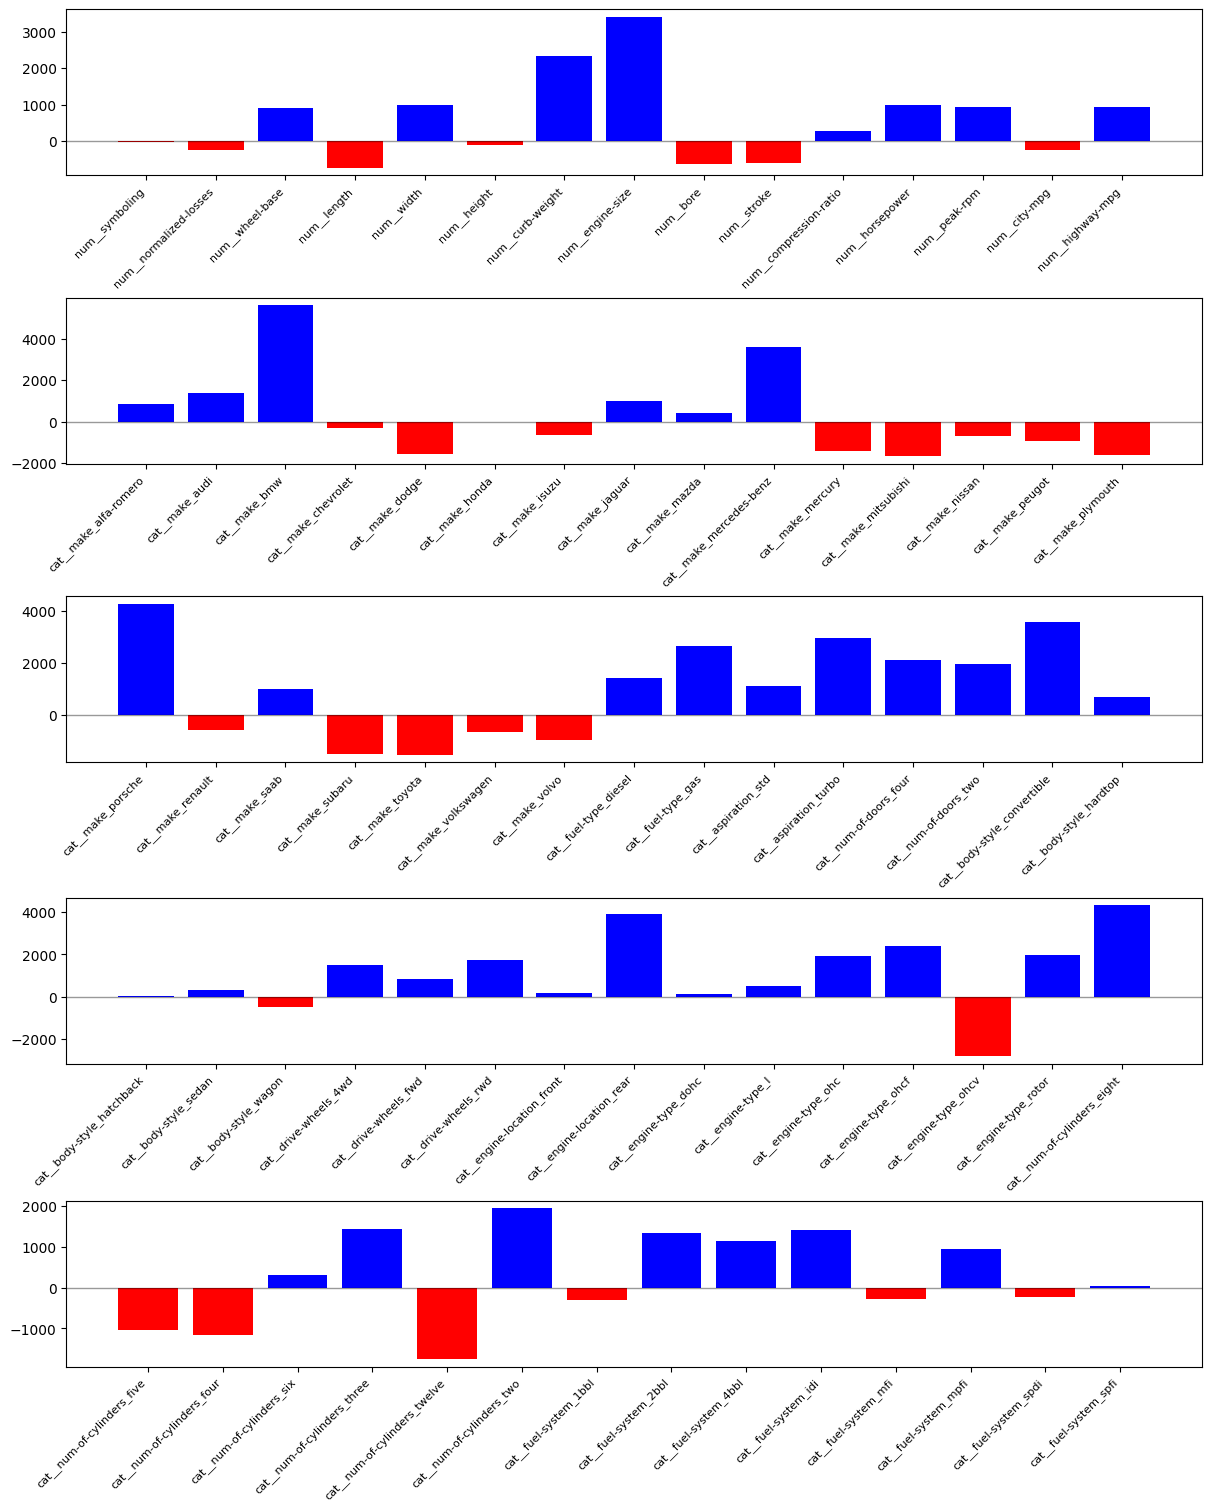

In [22]:
# 1. Extraer pesos del modelo

pesos = np.asarray(modelo.w_, dtype=float)  # coeficientes aprendidos por la NeuronaLineal
nombres = list(preprocesador.get_feature_names_out())  # nombres de las variables procesadas

# 2. Configuración para agrupar

tamaño_grupo = 15  # cantidad de atributos que se muestran por gráfico
n_grupos = int(np.ceil(len(pesos) / tamaño_grupo))  # número total de gráficos necesarios

# Crear subplots (un gráfico por grupo de atributos)
fig, ejes = plt.subplots(n_grupos, 1, figsize=(12, 3 * n_grupos), constrained_layout=True)
ejes = [ejes] if n_grupos == 1 else ejes  # aseguramos que siempre sea lista

# 3. Dibujar gráficos de barras

for indice_grupo, eje in enumerate(ejes):
    inicio = indice_grupo * tamaño_grupo
    fin = min((indice_grupo + 1) * tamaño_grupo, len(pesos))
    
    pesos_grupo = pesos[inicio:fin]       # pesos del grupo actual
    nombres_grupo = nombres[inicio:fin]   # nombres de atributos correspondientes
    indices = np.arange(len(pesos_grupo)) # posiciones en el eje X
    
    # Barras: azul si el peso es positivo, rojo si es negativo
    eje.bar(indices, pesos_grupo, color=np.where(pesos_grupo < 0, "red", "blue"))
    
    # Configuración de etiquetas y línea horizontal en cero
    eje.set_xticks(indices)
    eje.set_xticklabels(nombres_grupo, rotation=45, ha="right", fontsize=8)
    eje.axhline(0, lw=1, color="k", alpha=0.4)

# 4. Mostrar gráficos

plt.show()

# Regresión Logística Múltiple (varias variables de entrada y salida sigmoide en (0,1) o (-1,1))

## Ejercicio 8

El archivo **semillas.csv** contiene información de granos que pertenecen a tres variedades diferentes de trigo. Entrene una neurona no lineal para determinar si una semilla es de “TIPO 2” o no. Divida el 60% de los ejemplos para entrenar y el 40% para realizar el testeo. Antes de entrenar, normalice todos los atributos 
numéricos aplicando media y desvío. 

Realice los siguientes experimentos con el fin de analizar cómo distintos hiperparámetros afectan la convergencia y el desempeño del modelo:

1. Lleve a cabo **20 experimentos**, utilizando la función **sigmoide**, variando la **tasa de aprendizaje** desde **α = 0.04**, incrementando en pasos de **0.04** (es decir, α = 0.04, 0.08, ..., hasta 0.80). En cada experimento, registre: curva de **error** (error por iteración), curva de **accuracy** (precisión por iteración), cantidad total de 
iteraciones realizadas, la iteración en la que se alcanzó el 100% de accuracy.
2. Replique el punto a) utilizando **tangente hiperbólica**.
3. Compare y analice los resultados obtenidos a) y b).

In [23]:
from ClassNeuronaGral import NeuronaGradiente
from sklearn.model_selection import train_test_split

# 1. Cargar datos

semillas = pd.read_csv(
    r"C:\Users\Usuario\Desktop\FACULTAD\4to_Año\segundo_semestre\Aprendizaje Automatico Profundo\practicas\resoluciones\datasets\semillas.csv"
)

# 2. X: atributos, y: target binario (1 si tipo=2, 0 si no)

X = semillas.iloc[:, :-1].to_numpy()
y = (semillas.iloc[:, -1] == "Tipo2").astype(int).to_numpy()

# 3. Train/test split 60/40

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)

# 4. Normalización (media y desvío)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 5. Loop de tasas de aprendizaje
tasas = np.arange(0.04, 0.84, 0.04)  # 0.04 ... 0.80

resultados_sigmoid = []

for alpha in tasas:
    modelo = NeuronaGradiente(alpha=alpha, n_iter=500, FUN="sigmoid", random_state=42)
    modelo.fit(X_train, y_train)
    
    # accuracy final en train y test
    acc_train = modelo.accuracy(X_train, y_train)
    acc_test = modelo.accuracy(X_test, y_test)
    
    resultados_sigmoid.append({
        "alpha": alpha,
        "iteraciones": len(modelo.errors_),
        "errores": modelo.errors_,
        "accuracy_iter": modelo.accuracy_,
        "accuracy_train": acc_train,
        "accuracy_test": acc_test,
        "iter_100acc": next((i for i,a in enumerate(modelo.accuracy_) if a==1), None)
    })

print(resultados_sigmoid)

[{'alpha': np.float64(0.04), 'iteraciones': 500, 'errores': [np.float64(27.27586659525023), np.float64(15.318012715618007), np.float64(11.440305506013647), np.float64(9.454656762911998), np.float64(8.252073457053099), np.float64(7.452974682645573), np.float64(6.8878997107249225), np.float64(6.469242100358725), np.float64(6.147368641461017), np.float64(5.892309346236517), np.float64(5.685061314264849), np.float64(5.51308349559426), np.float64(5.3678127280388095), np.float64(5.243226637151332), np.float64(5.134978532720553), np.float64(5.039858553418657), np.float64(4.955447770226667), np.float64(4.879890094649949), np.float64(4.81173817532633), np.float64(4.749846968374114), np.float64(4.693298749637403), np.float64(4.641349309630173), np.float64(4.593388700569337), np.float64(4.548912161126492), np.float64(4.507498277791996), np.float64(4.46879237043258), np.float64(4.432493702533216), np.float64(4.398345528089248), np.float64(4.366127267789204), np.float64(4.335648301441586), np.float

In [24]:
# 2. X: atributos, y: target binario (1 si tipo=2, 0 si no)

X = semillas.iloc[:, :-1].to_numpy()
y = np.where(semillas.iloc[:, -1] == "Tipo2", 1, -1)

# 3. Train/test split 60/40

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)

# 4. Normalización (media y desvío)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 5. Loop de tasas de aprendizaje

resultados_tanh = []

for alpha in tasas:
    modelo = NeuronaGradiente(alpha=alpha, n_iter=500, FUN="tanh", random_state=42)
    modelo.fit(X_train, y_train)
    
    # accuracy final en train y test
    acc_train = modelo.accuracy(X_train, y_train)
    acc_test = modelo.accuracy(X_test, y_test)
    
    resultados_tanh.append({
        "alpha": alpha,
        "iteraciones": len(modelo.errors_),
        "errores": modelo.errors_,
        "accuracy_iter": modelo.accuracy_,
        "accuracy_train": acc_train,
        "accuracy_test": acc_test,
        "iter_100acc": next((i for i,a in enumerate(modelo.accuracy_) if a==1), None)
    })

print(resultados_tanh)

[{'alpha': np.float64(0.04), 'iteraciones': 500, 'errores': [np.float64(50.33697264489728), np.float64(20.8466493470063), np.float64(18.329381895700923), np.float64(17.120148527206087), np.float64(16.319003636587833), np.float64(15.717292879250456), np.float64(15.231942142849505), np.float64(14.820589779751474), np.float64(14.458421956609607), np.float64(14.129526845676644), np.float64(13.823014370232379), np.float64(13.531082003187679), np.float64(13.248009073509987), np.float64(12.969649272525556), np.float64(12.693206068948049), np.float64(12.417148827535733), np.float64(12.141142614876888), np.float64(11.86587650181046), np.float64(11.592731680119954), np.float64(11.323342492250765), np.float64(11.059204173393004), np.float64(10.801470469910962), np.float64(10.550956449831732), np.float64(10.308240664650512), np.float64(10.073752159743153), np.float64(9.847801008822548), np.float64(9.63057313120761), np.float64(9.422122328777357), np.float64(9.22237602235479), np.float64(9.03115455

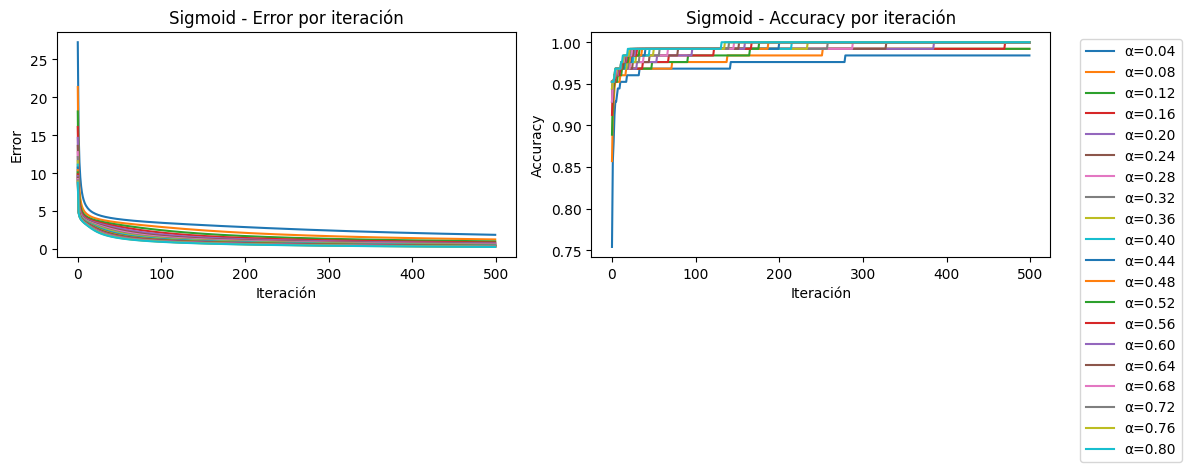

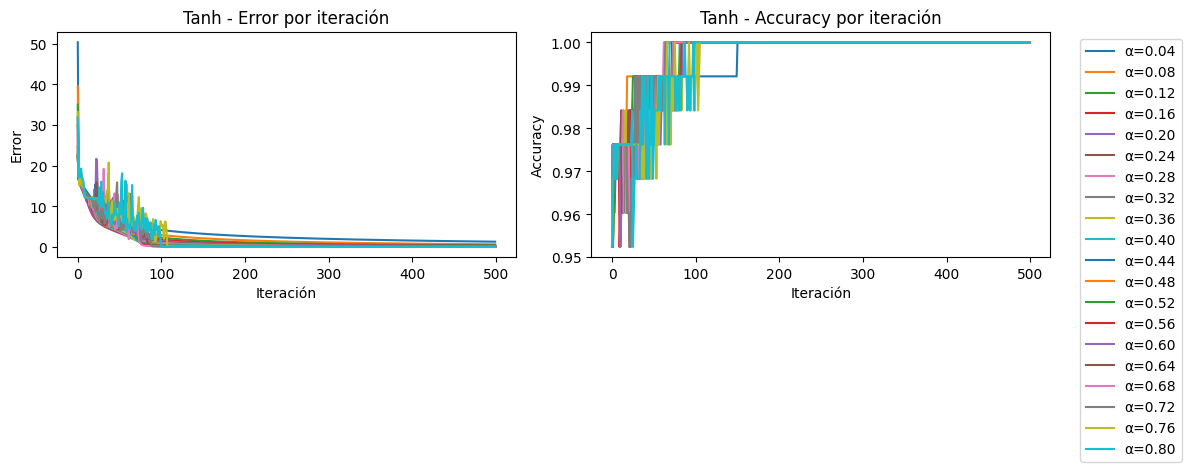

In [25]:
def plot_curvas(res, titulo):
    fig, axes = plt.subplots(1,2, figsize=(12,4))
    
    for r in res:
        axes[0].plot(r["errores"], label=f"α={r['alpha']:.2f}")
        axes[1].plot(r["accuracy_iter"], label=f"α={r['alpha']:.2f}")
    
    axes[0].set_title(f"{titulo} - Error por iteración")
    axes[0].set_xlabel("Iteración")
    axes[0].set_ylabel("Error")
    
    axes[1].set_title(f"{titulo} - Accuracy por iteración")
    axes[1].set_xlabel("Iteración")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend(bbox_to_anchor=(1.05,1), loc="upper left")
    
    plt.tight_layout()
    plt.show()

plot_curvas(resultados_sigmoid, "Sigmoid")
plot_curvas(resultados_tanh, "Tanh")

## Ejercicio 9

Se ha realizado un análisis químico a tres tipos distintos de vinos producidos en una misma región de Italia. El número de muestras considerado es el siguiente: $$\text{Tipo 1 ➔ 59 muestras, Tipo 2 ➔ 71 muestras, Tipo 3 ➔ 48 muestras}$$

El archivo vinos.csv permite observar los resultados de este análisis. Cada fila representa una muestra distinta y está formada, en primer lugar, por el número del tipo al cual pertenece el vino analizado seguido por los 13 atributos que lo caracterizan. Por ejemplo, la siguiente fila: $$2, 12.29, 3.17, 2.21, 18, 88, 2.85, 2.99, 0.45, 2.81, 2.3, 1.42, 2.83, 406$$ es el resultado del análisis de un vino correspondiente al tipo 2 (1er. valor de la fila) seguido por 13 valores 
separados por comas que indican los niveles de las mediciones realizadas a dicho vino.

1. Entrene una red neuronal formada por una única neurona para clasificar los vinos de Tipo 1.

Realice 30 ejecuciones independientes utilizando el 50%, 60%, 70%, 80% y 90% de los ejemplos como entrenamiento y el resto como testeo. Para cada porcentaje, indique la cantidad promedio de ejemplos correctamente clasificados en entrenamiento y en testeo. Calcule también el promedio y el desvío de la 
cantidad de iteraciones realizadas. 

Utilice un máximo de 400 iteraciones y velocidades de aprendizaje 0.1, 0.2 y 0.3. 

Analice los resultados obtenidos utilizando:

1. Función de activación ‘sigmoid’ y función de costo ‘ECM’ (error cuadrático medio).
2. Función de activación ‘sigmoid’ y función de costo ‘EC_binaria’ (entropía cruzada binaria)
3. Función de activación ‘tanh’ y función de costo ‘ECM’ (error cuadrático medio)

In [26]:
vinos = pd.read_csv(r"C:\Users\Usuario\Desktop\FACULTAD\4to_Año\segundo_semestre\Aprendizaje Automatico Profundo\practicas\resoluciones\datasets\Vinos.csv", delimiter=";")

# Preparamos las variables
standard_scaler = StandardScaler()
X = vinos.drop(columns=["Class"]).to_numpy(dtype=float)
X = standard_scaler.fit_transform(X)
y_sig = (vinos["Class"].to_numpy() == 1).astype(float)    # {0,1}
y_tnh = np.where(vinos["Class"].to_numpy() == 1, 1.0, -1.0)  # {-1,+1}

tam_entrenamientos = [0.5, 0.6, 0.7, 0.8, 0.9]
alphas = [0.1, 0.2, 0.3]
num_ejec = 30
max_ite = 400

modelos = [
    ("sigmoid", "ECM",        y_sig),
    ("sigmoid", "EC_binaria", y_sig),
    ("tanh",    "ECM",        y_tnh),
]

resultados = []

for tam_entrenamiento in tam_entrenamientos:
    for fun, costo, y in modelos:
        for alpha in alphas:
            for ejec in range(num_ejec):
                X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=tam_entrenamiento, random_state=ejec, stratify=y)
                modelo = NeuronaGradiente(
                    alpha=alpha,
                    n_iter=max_ite,
                    FUN=fun,
                    COSTO=costo,
                    random_state=ejec,
                    cotaE=1e-8
                )
                modelo.fit(X_train, y_train)
                # cantidad de correctos
                acc_train = modelo.accuracy(X_train, y_train) * len(y_train)
                acc_test  = modelo.accuracy(X_test, y_test) * len(y_test)
                num_iter  = len(modelo.errors_)
                
                resultados.append({
                    "tam_ent": tam_entrenamiento,
                    "FUN": fun,
                    "COSTO": costo,
                    "alpha": alpha,
                    "ejec": ejec,
                    "acc_train": acc_train,
                    "acc_test": acc_test,
                    "iter": num_iter
                })

df_res = pd.DataFrame(resultados)

resumen = df_res.groupby(["tam_ent", "FUN", "COSTO", "alpha"]).agg(
    acc_train_prom=("acc_train", "mean"),
    acc_test_prom=("acc_test", "mean"),
    iter_prom=("iter", "mean"),
    iter_std=("iter", "std")
).reset_index()

print(resumen)

    tam_ent      FUN       COSTO  alpha  acc_train_prom  acc_test_prom  \
0       0.5  sigmoid         ECM    0.1       89.000000      88.133333   
1       0.5  sigmoid         ECM    0.2       89.000000      88.100000   
2       0.5  sigmoid         ECM    0.3       89.000000      88.066667   
3       0.5  sigmoid  EC_binaria    0.1       89.000000      88.133333   
4       0.5  sigmoid  EC_binaria    0.2       89.000000      88.100000   
5       0.5  sigmoid  EC_binaria    0.3       89.000000      88.066667   
6       0.5     tanh         ECM    0.1       89.000000      88.066667   
7       0.5     tanh         ECM    0.2       89.000000      88.000000   
8       0.5     tanh         ECM    0.3       88.933333      87.933333   
9       0.6  sigmoid         ECM    0.1      106.000000      71.566667   
10      0.6  sigmoid         ECM    0.2      106.000000      71.533333   
11      0.6  sigmoid         ECM    0.3      106.000000      71.533333   
12      0.6  sigmoid  EC_binaria    0.

## Ejercicio 10

A partir de los ejemplos del archivo **automobile-simple.csv**, utilice todos los ejemplos para generar un modelo de 1 neurona para clasificar si un auto es ecológico: 

1. Elimine los registros que presenten valores faltantes y utilice el atributo eco-rating para generar un nuevo atributo binario que determine si un auto es ecológico o no. Considere que un auto es ecológico si el valor de "eco-rating" supera la media de dicho atributo.
2. Luego de completar según lo indicado en a), aplique normalización y realice el entrenamiento utilizando los atributos numéricos:
   1. Utilizando salida sigmoide (sigmoid) para la neurona.
   2. Utilizando salida tangente hiperbólico (tanh) para la neurona.

In [27]:
autos_simple = pd.read_csv(r"C:\Users\Usuario\Desktop\FACULTAD\4to_Año\segundo_semestre\Aprendizaje Automatico Profundo\practicas\resoluciones\datasets\automobile-simple.csv")
autos_simple = autos_simple.dropna(axis=0) # eliminamos las filas que tienen NaN

media_eco = autos_simple["eco-rating"].mean()
autos_simple["eco"] = (autos_simple["eco-rating"] > media_eco).astype(int)

X = autos_simple[["curb-weight","engine-size","horsepower","city-mpg","highway-mpg","price","volume"]].to_numpy(dtype=float)
y_sig = autos_simple["eco"].to_numpy(dtype=float)
y_tanh = np.where(autos_simple["eco"]==1, 1.0, -1.0)

standard_scaler = StandardScaler()
X = standard_scaler.fit_transform(X)

modelo_sig = NeuronaGradiente(
    alpha=0.01,
    n_iter=1000,
    cotaE=1e-8,
    FUN="sigmoid",
    random_state=42
)
modelo_sig.fit(X, y_sig)
acc_train_sig = modelo_sig.accuracy(X, y_sig)
print(f"Modelo Sigmoid: Accuracy train: {acc_train_sig:.2%} - Iteraciones: {len(modelo_sig.errors_)}")

modelo_tanh = NeuronaGradiente(
    alpha=0.01,
    n_iter=1000,
    cotaE=1e-8,
    FUN="tanh",
    random_state=42
)
modelo_tanh.fit(X, y_tanh)
acc_train_tanh = modelo_tanh.accuracy(X, y_tanh)
print(f"Modelo Sigmoid: Accuracy train: {acc_train_tanh:.2%} - Iteraciones: {len(modelo_tanh.errors_)}")

Modelo Sigmoid: Accuracy train: 97.97% - Iteraciones: 1000
Modelo Sigmoid: Accuracy train: 100.00% - Iteraciones: 1000


# Regresión Logística multiclase

## Ejercicio 11

Se busca predecir si el tipo de fármaco que se debe administrar a un paciente afectado de rinitis alérgica es el habitual o no. Se dispone de información correspondiente a las historias clínicas de pacientes atendidos previamente

1. Numerice los atributos nominales y utilice el archivo **drug_train.csv** para entrenar un modelo con 5 neuronas que sea capaz de predecir el tipo de fármaco que se debe administrar a un paciente afectado de rinitis alérgica.
2. Luego utilice el archivo **drug_test.csv** para medir la calidad del modelo.

In [28]:
from sklearn.preprocessing import LabelEncoder
from ClassRNMulticlase import RNMulticlase

drug_train = pd.read_csv(r"C:\Users\Usuario\Desktop\FACULTAD\4to_Año\segundo_semestre\Aprendizaje Automatico Profundo\practicas\resoluciones\datasets\drugs_train.csv")
drug_test = pd.read_csv(r"C:\Users\Usuario\Desktop\FACULTAD\4to_Año\segundo_semestre\Aprendizaje Automatico Profundo\practicas\resoluciones\datasets\drugs_test.csv")

X_train_raw = drug_train.drop(columns=["Drug"])
y_train_raw = drug_train["Drug"]

X_test_raw = drug_test.drop(columns=["Drug"])
y_test_raw = drug_test["Drug"]

# Atributos categóricos y numéricos
cat_cols = ["Sex", "BP", "Cholesterol"]
num_cols = ["Age", "Na", "K"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first"), cat_cols),
        ("num", StandardScaler(), num_cols),
    ]
)

# Aplicamos transformaciones
X_train = preprocessor.fit_transform(X_train_raw)
X_test = preprocessor.transform(X_test_raw)

# LabelEncoder para convertir a números
label_encoder = LabelEncoder()
y_train_int = label_encoder.fit_transform(y_train_raw)
y_test_int = label_encoder.transform(y_test_raw)

# OneHotEncoder para convertir a one-hot
y_train = np.eye(len(label_encoder.classes_))[y_train_int]
y_test = np.eye(len(label_encoder.classes_))[y_test_int]

print("Clases:", label_encoder.classes_)
print("Shape X_train:", X_train.shape, "Shape y_train:", y_train.shape)

modelo = RNMulticlase(
    alpha=0.01,
    n_iter=1000,
    FUN="sigmoid",
    cotaE=1e-6,
    random_state=42
)

modelo.fit(X_train, y_train)

acc_train = modelo.accuracy(X_train, y_train)
acc_test = modelo.accuracy(X_test, y_test)

print(f"Accuracy en entrenamiento: {acc_train:.2%}")
print(f"Accuracy en test: {acc_test:.2%}")

Clases: ['drugA' 'drugB' 'drugC' 'drugX' 'drugY']
Shape X_train: (160, 7) Shape y_train: (160, 5)
Accuracy en entrenamiento: 90.62%
Accuracy en test: 75.00%


## Ejercicio 12

Utilice una red neuronal formada por una única capa de salida de 3 neuronas para clasificar las muestras de vino del archivo Vinos.csv descripto en el ejercicio anterior.

Realice 30 ejecuciones independientes utilizando el 60% y 80% de los ejemplos como entrenamiento y el resto como testeo.

Utilice un máximo de 400 iteraciones y velocidades de aprendizaje 0.1, 0.2 y 0.3.

Complete la siguiente tabla con los resultados de las siguientes configuraciones 

1. Función de activación ‘sigmoid’ y función de costo ‘ECM’ (error cuadrático medio)
2. Función de activación ‘sigmoid’ y función de costo ‘EC_binaria’ (entropía cruzada binaria)
3. Función de activación ‘tanh’ y función de costo ‘ECM’ (error cuadrático medio)
4. Capa ‘Softmax’ y función de costo ‘EC’ (entropía cruzada) 

In [29]:
vinos = pd.read_csv(
    r"C:\Users\Usuario\Desktop\FACULTAD\4to_Año\segundo_semestre\Aprendizaje Automatico Profundo\practicas\resoluciones\datasets\Vinos.csv",
    delimiter=";"
)

scaler = StandardScaler()
X = vinos.drop(columns=["Class"]).to_numpy(dtype=float)
X = scaler.fit_transform(X)

classes = vinos["Class"].to_numpy().reshape(-1,1)
encoder = OneHotEncoder(sparse_output=False)
y_onehot = encoder.fit_transform(classes)   # etiquetas {0,1}
y_onehot_tanh = np.where(y_onehot==1, 1.0, -1.0) # {-1,1}

tam_entrenamientos = [0.6, 0.8]
alphas = [0.1, 0.2, 0.3]
num_ejec = 30
max_ite = 400

modelos = [
    ("sigmoid", "ECM",        y_onehot),
    ("sigmoid", "EC_binaria", y_onehot),
    ("tanh",    "ECM",        y_onehot_tanh),
    ("softmax", "EC",         y_onehot),
]

resultados = []

for tam_entrenamiento in tam_entrenamientos:
    for fun, costo, y in modelos:
        for alpha in alphas:
            for ejec in range(num_ejec):
                X_train, X_test, y_train, y_test = train_test_split(
                    X, y, 
                    train_size=tam_entrenamiento, 
                    random_state=ejec,
                    stratify=classes   # estratificado según clase original
                )

                modelo = RNMulticlase(
                    alpha=alpha,
                    n_iter=max_ite,
                    FUN=fun,
                    COSTO=costo,
                    random_state=ejec,
                    cotaE=1e-8
                )
                modelo.fit(X_train, y_train)

                # Métricas
                acc_train = modelo.accuracy(X_train, y_train)
                acc_test  = modelo.accuracy(X_test, y_test)
                num_iter  = len(modelo.errors_)

                resultados.append({
                    "tam_ent": tam_entrenamiento,
                    "FUN": fun,
                    "COSTO": costo,
                    "alpha": alpha,
                    "ejec": ejec,
                    "acc_train": acc_train,
                    "acc_test": acc_test,
                    "iter": num_iter
                })

df_res = pd.DataFrame(resultados)

resumen = df_res.groupby(["tam_ent", "FUN", "COSTO", "alpha"]).agg(
    acc_train_prom=("acc_train", "mean"),
    acc_test_prom=("acc_test", "mean"),
    iter_prom=("iter", "mean"),
    iter_std=("iter", "std")
).reset_index()

print(resumen)

    tam_ent      FUN       COSTO  alpha  acc_train_prom  acc_test_prom  \
0       0.6  sigmoid         ECM    0.1        0.990881       0.920370   
1       0.6  sigmoid         ECM    0.2        0.990881       0.920370   
2       0.6  sigmoid         ECM    0.3        0.990881       0.917130   
3       0.6  sigmoid  EC_binaria    0.1        0.990881       0.921759   
4       0.6  sigmoid  EC_binaria    0.2        0.990881       0.917130   
5       0.6  sigmoid  EC_binaria    0.3        0.990881       0.916667   
6       0.6  softmax          EC    0.1        0.994025       0.912037   
7       0.6  softmax          EC    0.2        0.992138       0.907407   
8       0.6  softmax          EC    0.3        0.989623       0.903704   
9       0.6     tanh         ECM    0.1        0.989937       0.915741   
10      0.6     tanh         ECM    0.2        0.989623       0.915741   
11      0.6     tanh         ECM    0.3        0.989308       0.918056   
12      0.8  sigmoid         ECM    0.